In [43]:
import numpy
from multiprocessing import Manager

class fastaReader():


    def __init__(self):
        self.path = "/content/multifasta.fasta"

        self.seqs = list()
        self.names = list()
        self.read()


    def read(self):
        f = open(self.path, "r")
        lines = f.readlines()
        f.close()
        seq = ""
        for line in lines:
            if line[0] == ">":
                self.names.append(line[1:].strip())
                if seq != "":
                    self.seqs.append(seq)
                seq = ""
            else:
                seq += line.strip()
        self.seqs.append(seq)

In [44]:
!pip install blosum

In [45]:
import blosum as bl

class evaluadorBlosum():

    def __init__(self):
        matrix = bl.BLOSUM(62)

        self.matrix = matrix

    def showMatrix(self):
        print(self.matrix)

    def getScore(self, A, B):
        #si alguno de los dos es un gap
        if A == "-" or B == "-":
            return -8
        score = self.matrix[A][B]
        return score


    pass

In [46]:
import copy
import math
from multiprocessing import Manager, Pool, managers
from pickle import FALSE, TRUE
#from evaluadorBlosum import evaluadorBlosum
import numpy
#from fastaReader import fastaReader
import random
from copy import copy
import copy
import concurrent.futures


class bacteria():


    def __init__(self, numBacterias):
        # manager = Manager()
        manager = Manager()
        self.blosumScore = manager.list(range(numBacterias))
        self.tablaAtract = manager.list(range(numBacterias))
        self.tablaRepel = manager.list(range(numBacterias))
        self.tablaInteraction = manager.list(range(numBacterias))
        self.tablaFitness = manager.list(range(numBacterias))
        self.granListaPares = manager.list(range(numBacterias))
        self.NFE = manager.list(range(numBacterias))

    def resetListas(self, numBacterias):
        manager = Manager()
        self.blosumScore = manager.list(range(numBacterias))
        self.tablaAtract = manager.list(range(numBacterias))
        self.tablaRepel = manager.list(range(numBacterias))
        self.tablaInteraction = manager.list(range(numBacterias))
        self.tablaFitness = manager.list(range(numBacterias))
        self.granListaPares = manager.list(range(numBacterias))
        self.NFE = manager.list(range(numBacterias))



    def cuadra(self, numSec, poblacion):
        #ciclo para recorrer poblacion
        for i in range(len(poblacion)):
            #obtiene las secuencias de la bacteria
            bacterTmp = poblacion[i]
            # print("bacterTmp: ", bacterTmp)
            bacterTmp = list(bacterTmp)
            # print("bacterTmp: ", bacterTmp)
            bacterTmp = bacterTmp[:numSec]
            # obtiene el tama�o de la secuencia m�s larga
            maxLen = 0
            for j in range(numSec):
                if len(bacterTmp[j]) > maxLen:
                    maxLen = len(bacterTmp[j])
                    #rellena con gaps las secuencias m�s cortas
                    for t in range(numSec):
                        gap_count = maxLen - len(bacterTmp[t])
                        if gap_count > 0:
                            bacterTmp[t].extend(["-"] * gap_count)
                            #actualiza la poblacion
                            poblacion[i] = tuple(bacterTmp)









    """metodo que recorre la matriz y elimina las columnas con gaps en todos los elementos"""
    def limpiaColumnas(self):
        i = 0
        while i < len(self.matrix.seqs[0]):
            if self.gapColumn(i):
                self.deleteCulmn(i)
            else:
                i += 1



        """metodo para eliminar un elemento especifico en cada secuencia"""
    def deleteCulmn(self, pos):
        for i in range(len(self.matrix.seqs)):
            self.matrix.seqs[i] = self.matrix.seqs[i][:pos] + self.matrix.seqs[i][pos+1:]



    """metodo para saber si alguna columna de self.matrix tiene  gap en todos los elementos"""
    def gapColumn(self, col):
        for i in range(len(self.matrix.seqs)):
            if self.matrix.seqs[i][col] != "-":
                return False
        return True



    def tumbo(self, numSec, poblacion, numGaps):
      for i in range(len(poblacion)):
        bacterTmp = list(poblacion[i])
        columnas_diversas = []
        for col in range(len(bacterTmp[0])):
            chars = set()
            for fila in range(numSec):
                if col < len(bacterTmp[fila]):
                    chars.add(bacterTmp[fila][col])
            columnas_diversas.append((col, len(chars)))
        columnas_diversas.sort(key=lambda x: x[1], reverse=True)

        for j in range(numGaps):
            seqnum = random.randint(0, numSec - 1)
            if columnas_diversas:
                pos = columnas_diversas[j % len(columnas_diversas)][0]
            else:
                pos = random.randint(0, len(bacterTmp[seqnum]))
            part1 = bacterTmp[seqnum][:pos]
            part2 = bacterTmp[seqnum][pos:]
            bacterTmp[seqnum] = part1 + ["-"] + part2

        poblacion[i] = tuple(bacterTmp)





    def creaGranListaPares(self, poblacion):
        # granListaPares = list(range(len(poblacion)))
        #ciclo para recorrer poblacion
        for i in range(len(poblacion)):  #recorre poblacion
            pares = list()
            bacterTmp = poblacion[i]
            bacterTmp = list(bacterTmp)
            #ciclo para recorrer secuencias
            for j in range(len(bacterTmp)):     #recorre secuencias de bacteria
                column = self.getColumn(bacterTmp, j)
                pares = pares + self.obtener_pares_unicos(column)
            self.granListaPares[i] = pares
            # print("Bacteria: ", i, " Pares: ", pares)

        # return self.granListaPares



    def evaluaFila(self, fila, num):
      evaluador = evaluadorBlosum()
      score = 0
      gap_penalty = 0
      for par in fila:
          if "-" in par:
              gap_penalty += 4  # penaliza si hay gaps
          score += evaluador.getScore(par[0], par[1])
      final_score = score - gap_penalty  # fitness penalizado
      self.blosumScore[num] = final_score

    def evaluaBlosum(self):
        with Pool() as pool:
            args = [(copy.deepcopy(self.granListaPares[i]), i) for i in range(len(self.granListaPares))]
            pool.starmap(self.evaluaFila, args)


    def getColumn(self, bacterTmp, colNum):
        column = []
        #obtiene las secuencias de la bacteria
        # bacterTmp = poblacion[bactNum]
        # bacterTmp = list(bacterTmp)
        #obtiene el caracter de cada secuencia en la columna
        for i in range(len(bacterTmp)):
            column.append(bacterTmp[i][colNum])
        return column





    def obtener_pares_unicos(self, columna):
        pares_unicos = set()
        for i in range(len(columna)):
            for j in range(i+1, len(columna)):
                par = tuple(sorted([columna[i], columna[j]]))
                pares_unicos.add(par)
        return list(pares_unicos)

    #------------------------------------------------------------Atract y Repel lineal




    def compute_diff(self, args):
        indexBacteria, otherBlosumScore, self.blosumScore, d, w = args
        diff = (self.blosumScore[indexBacteria] - otherBlosumScore) ** 2.0
        self.NFE[indexBacteria] += 1
        return d * numpy.exp(w * diff)

    def compute_cell_interaction(self, indexBacteria, d, w, atracTrue):
        with Pool() as pool:
            args = [(indexBacteria, otherBlosumScore, self.blosumScore, d, w) for otherBlosumScore in self.blosumScore]
            results = pool.map(self.compute_diff, args)
            pool.close()  # Close the pool to prevent any more tasks from being submitted
            pool.join()   # Wait for the worker processes to exit

        total = sum(results)

        if atracTrue:
            self.tablaAtract[indexBacteria] = total
        else:
            self.tablaRepel[indexBacteria] = total



    def creaTablaAtract(self, poblacion, d, w):                   #lineal
        for indexBacteria in range(len(poblacion)):
            self.compute_cell_interaction(indexBacteria,d, w, TRUE)
            # print("invocando indexBacteria numero: ", indexBacteria)
        # print("tablaAtract: ", self.tablaAtract)

    def creaTablaRepel(self, poblacion, d, w):                   #lineal
        for indexBacteria in range(len(poblacion)):
            self.compute_cell_interaction(indexBacteria,d, w, FALSE)
            # print("invocando indexBacteria numero: ", indexBacteria)
        # print("tablaAtract: ", self.tablaAtract)

    def creaTablasAtractRepel(self, poblacion, dAttr, wAttr, dRepel, wRepel):
        #invoca ambos metodos en paralelo
        with concurrent.futures.ThreadPoolExecutor() as executor:
            executor.submit(self.creaTablaAtract, poblacion, dAttr, wAttr)
            executor.submit(self.creaTablaRepel, poblacion, dRepel, wRepel)




            #-----------------------------------------------------------

    def creaTablaInteraction(self):
        #llena la tabla con la suma de atract y repel
        for i in range(len(self.tablaAtract)):
            self.tablaInteraction[i] = self.tablaAtract[i] + self.tablaRepel[i]

    def creaTablaFitness(self):
        #llena la tabla con la suma de interaction y blosumScore
        for i in range(len(self.tablaInteraction)):
            valorBlsm = self.blosumScore[i]
            valorInteract = self.tablaInteraction[i]
            #suma ambos valores
            valorFitness =  valorBlsm + valorInteract

            self.tablaFitness[i] = valorFitness

    def getNFE(self):
        return sum(self.NFE)


    def obtieneBest(self, globalNFE):
        bestIdx = 0
        for i in range(len(self.tablaFitness)):
            if self.tablaFitness[i] > self.tablaFitness[bestIdx]:
                bestIdx = i
        print("-------------------   Best: ", bestIdx, " Fitness: ", self.tablaFitness[bestIdx], "BlosumScore ",  self.blosumScore[bestIdx], "Interaction: ", self.tablaInteraction[bestIdx], "NFE: ", globalNFE)
        return bestIdx, self.tablaFitness[bestIdx]

    def replaceWorst(self, poblacion, best):
      worst = 0
      for i in range(len(self.tablaFitness)):
          if self.tablaFitness[i] < self.tablaFitness[worst]:
             worst = i

      # Copiamos la mejor bacteria
      nueva = copy.deepcopy(poblacion[best])
      nueva = list(nueva)  # la bacteria es una tupla de listas → convertir a lista

     # Mutación: insertar 1 gap aleatorio en una de sus secuencias
      seq_idx = random.randint(0, len(nueva) - 1)
      secuencia = list(nueva[seq_idx])  # aseguramos que la secuencia es mutable
      pos = random.randint(0, len(secuencia))
      secuencia.insert(pos, "-")
      nueva[seq_idx] = secuencia  # actualizamos la secuencia mutada

    # Guardamos la nueva bacteria mutada
      poblacion[worst] = tuple(nueva)





In [40]:
!pip install seaborn

Running iteration 1/30
-------------------   Best:  14  Fitness:  28.5 BlosumScore  13.0 Interaction:  15.5 NFE:  551
-------------------   Best:  14  Fitness:  28.5 BlosumScore  13.0 Interaction:  15.5 NFE:  1088
-------------------   Best:  14  Fitness:  28.5 BlosumScore  13.0 Interaction:  15.5 NFE:  1624
-------------------   Best:  14  Fitness:  28.5 BlosumScore  13.0 Interaction:  15.5 NFE:  2164
-------------------   Best:  14  Fitness:  28.5 BlosumScore  13.0 Interaction:  15.5 NFE:  2702
Running iteration 2/30
-------------------   Best:  14  Fitness:  28.5 BlosumScore  13.0 Interaction:  15.5 NFE:  546
-------------------   Best:  14  Fitness:  28.5 BlosumScore  13.0 Interaction:  15.5 NFE:  1087
-------------------   Best:  14  Fitness:  28.5 BlosumScore  13.0 Interaction:  15.5 NFE:  1623
-------------------   Best:  14  Fitness:  28.5 BlosumScore  13.0 Interaction:  15.5 NFE:  2162
-------------------   Best:  14  Fitness:  28.5 BlosumScore  13.0 Interaction:  15.5 NFE:  2

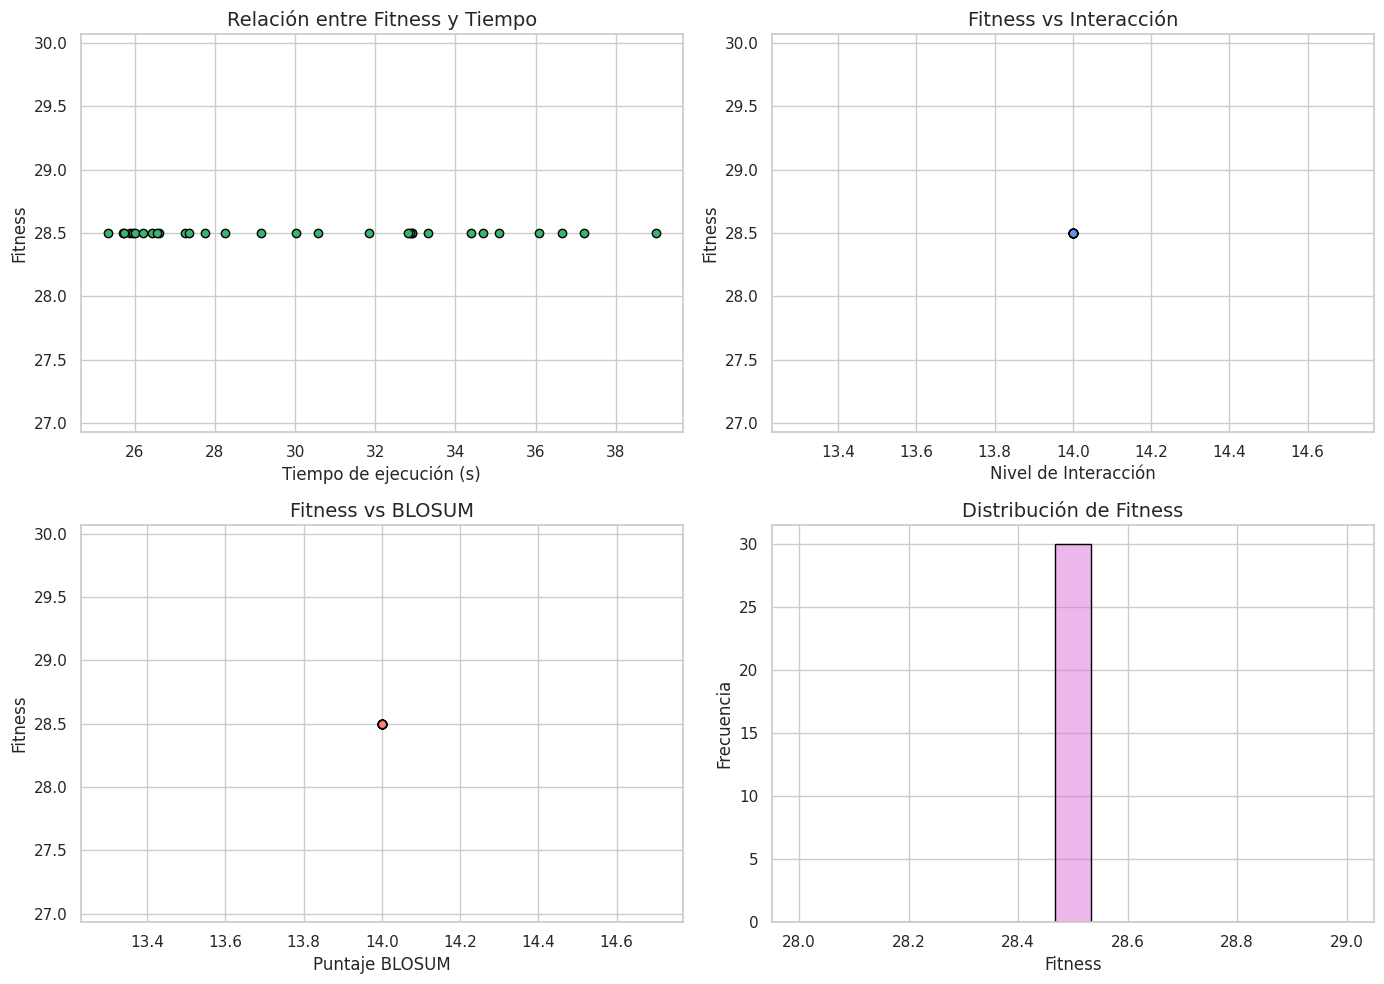

In [47]:
from copy import copy
from multiprocessing import Manager
import time
#from bacteria import bacteria
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from fastaReader import fastaReader
import copy
import seaborn as sns
import matplotlib.pyplot as plt

def run_algorithm(numeroDeBacterias, iteraciones, tumbo, dAttr, wAttr, hRep, wRep):
    secuencias = fastaReader().seqs
    names = fastaReader().names

    # Convertir las secuencias en listas de caracteres
    for i in range(len(secuencias)):
        secuencias[i] = list(secuencias[i])

    globalNFE = 0  # Número de evaluaciones de la función objetivo
    manager = Manager()
    numSec = len(secuencias)
    poblacion = manager.list(range(numeroDeBacterias))
    names = manager.list(names)
    NFE = manager.list(range(numeroDeBacterias))

    def poblacionInicial():
        for i in range(numeroDeBacterias):
            bacterium = []
            for j in range(numSec):
                bacterium.append(secuencias[j])
            poblacion[i] = list(bacterium)

    operadorBacterial = bacteria(numeroDeBacterias)
    veryBest = [None, None, None]  # [índice, fitness, secuencias]
    start_time = time.time()

    poblacionInicial()
    for it in range(iteraciones):
        operadorBacterial.tumbo(numSec, poblacion, tumbo)
        operadorBacterial.cuadra(numSec, poblacion)
        operadorBacterial.creaGranListaPares(poblacion)
        operadorBacterial.evaluaBlosum()
        operadorBacterial.creaTablasAtractRepel(poblacion, dAttr, wAttr, hRep, wRep)
        operadorBacterial.creaTablaInteraction()
        operadorBacterial.creaTablaFitness()
        globalNFE += operadorBacterial.getNFE()
        bestIdx, bestFitness = operadorBacterial.obtieneBest(globalNFE)

        # Actualizar la mejor solución encontrada
        if (veryBest[0] is None) or (bestFitness > veryBest[1]):
            veryBest[0] = bestIdx
            veryBest[1] = bestFitness
            veryBest[2] = copy.deepcopy(poblacion[bestIdx])

        # Reemplazar la peor bacteria por una copia de la mejor
        operadorBacterial.replaceWorst(poblacion, veryBest[0])
        operadorBacterial.resetListas(numeroDeBacterias)

    # Calcular el tiempo de ejecución
    execution_time = time.time() - start_time

    # Devolver los resultados de la ejecución
    return {
        "fitness": veryBest[1],
        "time": execution_time,
        "interaction": operadorBacterial.tablaInteraction[veryBest[0]],
        "blosum_score": operadorBacterial.blosumScore[veryBest[0]]
    }

def performance_analysis(runs=30):
    results = []
    parameters = {
        "numeroDeBacterias": 15,
        "iteraciones": 5,
        "tumbo": 50,
        "dAttr": 0.1,
        "wAttr": 0.002,
        "hRep": 0.1,
        "wRep": 0.001
    }

    # Ejecutar las corridas
    for run in range(runs):
        print(f"Running iteration {run + 1}/{runs}")
        result = run_algorithm(**parameters)
        results.append(result)

    df = pd.DataFrame(results)
    df.to_csv("resultados_BFOA.csv", index=False)
    return df

def plot_results(df):
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(14, 10))

    # Gráfico 1: Fitness vs Tiempo de ejecución
    plt.subplot(2, 2, 1)
    plt.scatter(df['time'], df['fitness'], color='mediumseagreen', edgecolors='black')
    plt.xlabel('Tiempo de ejecución (s)', fontsize=12)
    plt.ylabel('Fitness', fontsize=12)
    plt.title('Relación entre Fitness y Tiempo', fontsize=14)
    plt.grid(True)

    # Gráfico 2: Fitness vs Interacción
    plt.subplot(2, 2, 2)
    plt.scatter(df['interaction'], df['fitness'], color='cornflowerblue', edgecolors='black')
    plt.xlabel('Nivel de Interacción', fontsize=12)
    plt.ylabel('Fitness', fontsize=12)
    plt.title('Fitness vs Interacción', fontsize=14)
    plt.grid(True)

    # Gráfico 3: Fitness vs BLOSUM Score
    plt.subplot(2, 2, 3)
    plt.scatter(df['blosum_score'], df['fitness'], color='salmon', edgecolors='black')
    plt.xlabel('Puntaje BLOSUM', fontsize=12)
    plt.ylabel('Fitness', fontsize=12)
    plt.title('Fitness vs BLOSUM', fontsize=14)
    plt.grid(True)

    # Gráfico 4: Histograma de Fitness
    plt.subplot(2, 2, 4)
    sns.histplot(df['fitness'], bins=15, kde=True, color='orchid', edgecolor='black')
    plt.xlabel('Fitness', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.title('Distribución de Fitness', fontsize=14)
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("analisis_BFOA.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    # Ejecutar el análisis de desempeño con 30 corridas
    df = performance_analysis(runs=30)

    # Generar y mostrar los gráficos
    plot_results(df)